# Extreme (Xarray): computing EFI and SOT

In [1]:
import earthkit.data as ekd
import earthkit.plots as ekp

from earthkit.meteo import extreme

### Getting the data

The sample forecast contains ensemble 2 m temperature data and the second sample contains the corresponding model-climate information. EFI and SOT compare the forecast distribution against that model climate for the same parameter, lead time and time of year.

In [2]:
ds_fc = ekd.from_source("sample", "extreme_2t_fc.grib").to_xarray()
ds_fc

extreme_2t_fc.grib:   0%|          | 0.00/81.3M [00:00<?, ?B/s]

<xarray.Dataset> Size: 347MB
Dimensions:    (member: 101, values: 421120)
Coordinates:
  * member     (member) <U3 1kB '0' '1' '10' '100' '11' ... '96' '97' '98' '99'
    latitude   (values) float64 3MB ...
    longitude  (values) float64 3MB ...
Dimensions without coordinates: values
Data variables:
    2t         (member, values) float64 340MB ...
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

Next, we load the model-climate data used as the reference distribution.

In [3]:
ds_clim = ekd.from_source("sample", "extreme_2t_clim.grib").to_xarray()
ds_clim

extreme_2t_clim.grib:   0%|          | 0.00/61.0M [00:00<?, ?B/s]

<xarray.Dataset> Size: 347MB
Dimensions:    (member: 101, values: 421120)
Coordinates:
  * member     (member) <U3 1kB '0' '1' '10' '100' '11' ... '96' '97' '98' '99'
    latitude   (values) float64 3MB ...
    longitude  (values) float64 3MB ...
Dimensions without coordinates: values
Data variables:
    avg_2t     (member, values) float64 340MB ...
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

### Extreme Forecast Index

EFI measures how unusual the ensemble forecast distribution is relative to model climate. ECMWF defines it from the difference between the forecast and model-climate cumulative distribution functions, with extra weight given to the tails of the distribution. EFI values lie between -1 and 1. In practice, EFI values around 0.5 to 0.8 often indicate unusual conditions, while values above about 0.8 suggest very unusual or extreme conditions. For 2 m temperature, positive EFI highlights unusually warm conditions and negative EFI highlights unusually cold conditions.

References: [ECMWF Forecast User Guide: EFI and SOT overview](https://confluence.ecmwf.int/display/FUG/Section%2B8.1.9%2BExtreme%2BForecast%2BIndex%2B-%2BEFI%2C%2Band%2BShift%2Bof%2BTails%2B-%2BSOT), [ECMWF Forecast User Guide: calculating EFI](https://confluence.ecmwf.int/display/FUG/Section%2B8.1.9.2%2BExtreme%2BForecast%2BIndex%2B-%2BEFI), [Introducing earthkit](https://www.ecmwf.int/en/newsletter/179/computing/introducing-earthkit).

In [4]:
efi = extreme.efi(ds_clim["avg_2t"], ds_fc["2t"])

Finally, we plot the EFI field to identify the regions where the forecast departs most strongly from model climate. This version keeps the custom map styling added in the concurrent changes.

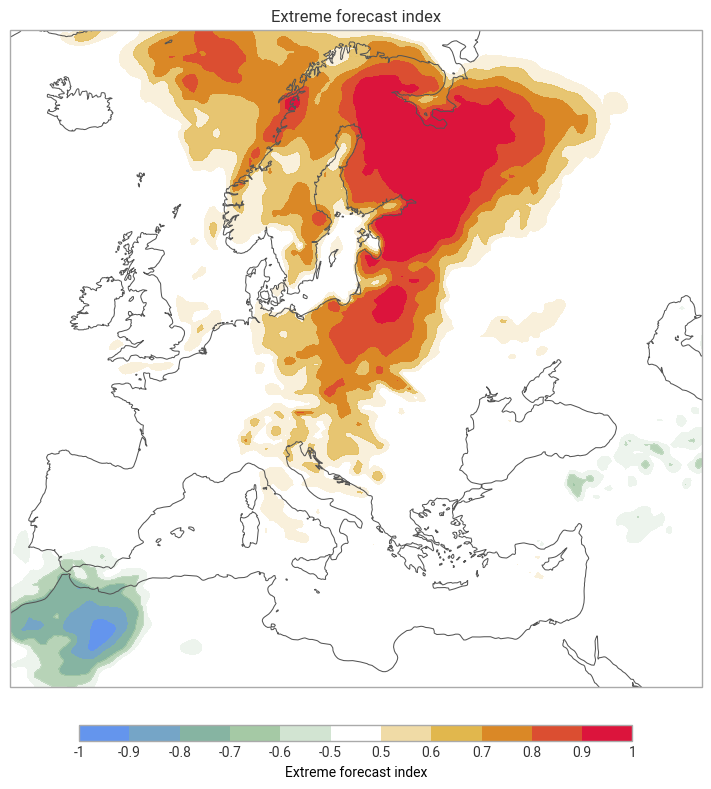

In [5]:
efi_style = ekp.styles.Style(
    levels=[-1, -0.9, -0.8, -0.7, -0.6, -0.5, 0.5, 0.6, 0.7, 0.8, 0.9, 1],
    colors=["cornflowerblue", "darkseagreen", (1, 1, 1, 0), "goldenrod", "crimson"],
)

chart = ekp.Map(domain="Europe")

chart.contourf(
    efi,
    style=efi_style,
)

chart.coastlines()
chart.title("Extreme forecast index")
chart.legend(label="Extreme forecast index")

chart.show()

### Shift of Tails

SOT complements EFI. ECMWF notes that EFI alone does not distinguish between ensemble members that merely reach the model-climate extreme and members that go well beyond it. SOT was introduced to describe how far the forecast tail extends relative to model climate. In the upper tail, ECMWF defines SOT from the 90th and 99th percentiles of the ensemble and model-climate distributions. Positive SOT indicates that at least 10% of the ensemble is forecasting an extreme event.

Reference: [ECMWF Forecast User Guide: calculating SOT](https://confluence.ecmwf.int/display/FUG/Section%2B8.1.9.3%2BCalculating%2Bthe%2BShift%2Bof%2BTails%2B-%2BSOT).

In [6]:
sot = extreme.sot(ds_clim["avg_2t"], ds_fc["2t"], 90)

As with EFI, a quick plot is useful for checking where the most pronounced tail shifts are located. We overlay SOT with the previously computed EFI.

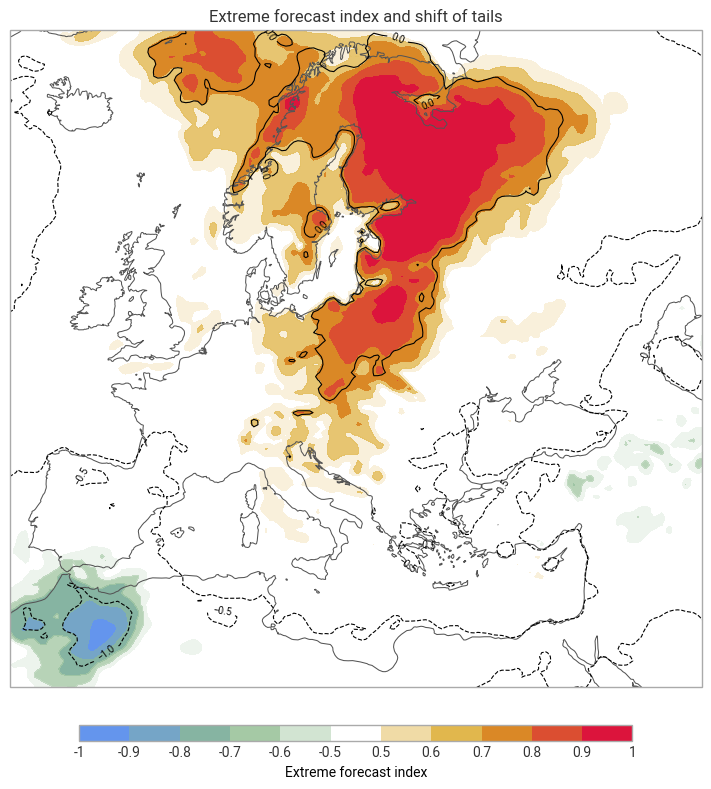

In [13]:
chart = ekp.Map(domain="Europe")

chart.contour(
    sot,
    levels=[-2, -1.5, -1, -0.5, 0, 0.5, 1],
    # levels=[0, 1, 2, 5, 8],
    colors="black",
    linewidths=0.8,
    legend_style=None,
)

chart.contourf(efi, style=efi_style)

chart.coastlines()
chart.title("Extreme forecast index and shift of tails")
chart.legend(label="Extreme forecast index")

chart.show()